# Инжиниринг категориальных признаков

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [8]:
# Предполагается, что файл customer_support.csv находится в текущей директории
url_customer = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/Customer_support_data.csv"
CS_data = pd.read_csv(url_customer)

#CS_data = pd.read_csv("customer_support.csv")
CS_data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [9]:
CS_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  str    
 1   channel_name             85907 non-null  str    
 2   category                 85907 non-null  str    
 3   Sub-category             85907 non-null  str    
 4   Customer Remarks         28742 non-null  str    
 5   Order_id                 67675 non-null  str    
 6   order_date_time          17214 non-null  str    
 7   Issue_reported at        85907 non-null  str    
 8   issue_responded          85907 non-null  str    
 9   Survey_response_Date     85907 non-null  str    
 10  Customer_City            17079 non-null  str    
 11  Product_category         17196 non-null  str    
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name               85907 no

In [10]:
CS_data.describe(include="all")

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,17206.000000,242.000000,85907,85907,85907,85907,85907,85907.000000
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,NaN,NaN,1371,40,6,5,5,NaN
top,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Inbound,Returns,Reverse Pickup Enquiry,Good,c27c9bb4-fa36-4140-9f1f-21009254ffdb,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,NaN,NaN,Wendy Taylor,Carter Park,John Smith,>90,Morning,NaN
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,NaN,NaN,429,4273,25261,30660,41426,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5660.774846,462.400826,NaN,NaN,NaN,NaN,NaN,4.242157
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12825.728411,246.295037,NaN,NaN,NaN,NaN,NaN,1.378903
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,392.000000,293.000000,NaN,NaN,NaN,NaN,NaN,4.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,979.000000,427.000000,NaN,NaN,NaN,NaN,NaN,5.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2699.750000,592.250000,NaN,NaN,NaN,NaN,NaN,5.000000


In [12]:
url_titanic = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/titanic.csv"
T_data = pd.read_csv(url_titanic)
T_data.head()
T_data.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
T_data.describe(exclude=[np.number])

,Pclass,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,891,204,889
unique,3,891,2,681,147,3
top,third,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,491,1,577,7,4,644


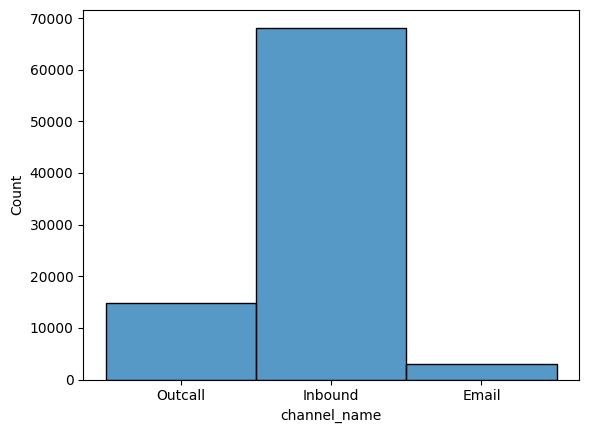

In [14]:
sns.histplot(data=CS_data, x="channel_name")
plt.show()

In [15]:
CS_data.channel_name.value_counts()

channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64

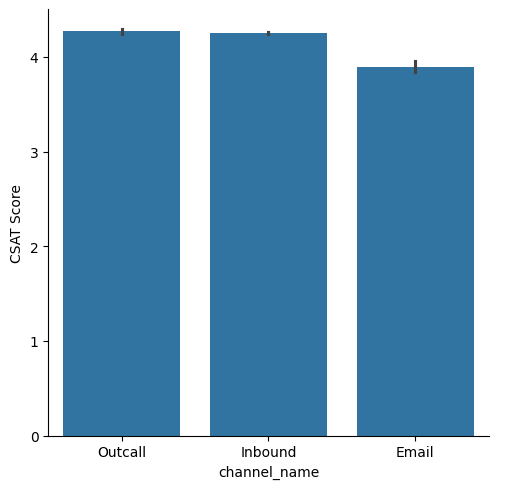

In [16]:
sns.catplot(data=CS_data, x="channel_name", y="CSAT Score", kind="bar")
plt.show()

In [17]:
CS_data.category.value_counts()

category
Returns               44097
Order Related         23215
Refund Related         4550
Product Queries        3692
Shopzilla Related      2792
Payments related       2327
Feedback               2294
Cancellation           2212
Offers & Cashback       480
Others                   99
App/website              84
Onboarding related       65
Name: count, dtype: int64

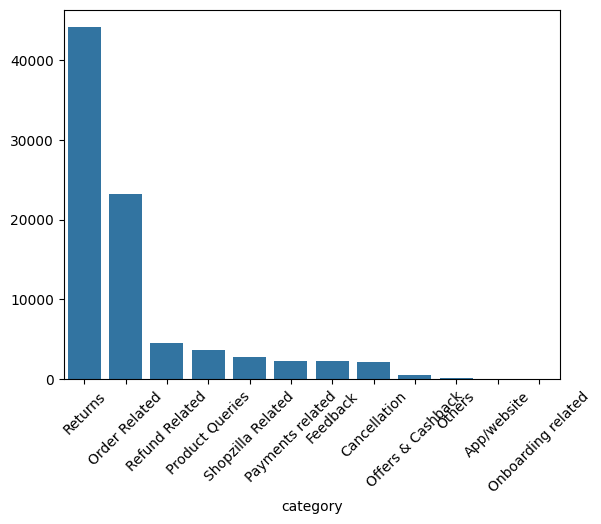

In [18]:
counts = CS_data.category.value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.show()

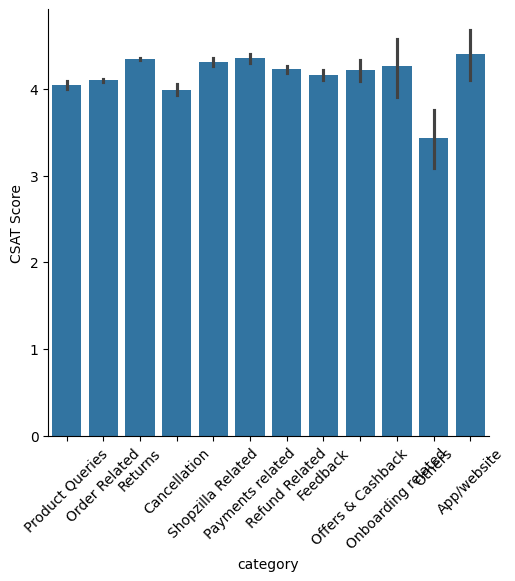

In [19]:
sns.catplot(data=CS_data, x="category", y="CSAT Score", kind="bar")
plt.xticks(rotation=45)
plt.show()

In [20]:
CS_data["Sub-category"].value_counts().head(10)

Sub-category
Reverse Pickup Enquiry          22389
Return request                   8523
Delayed                          7388
Order status enquiry             6922
Installation/demo                4116
Fraudulent User                  4108
Product Specific Information     3589
Refund Enquiry                   2665
Wrong                            2597
Missing                          2556
Name: count, dtype: int64

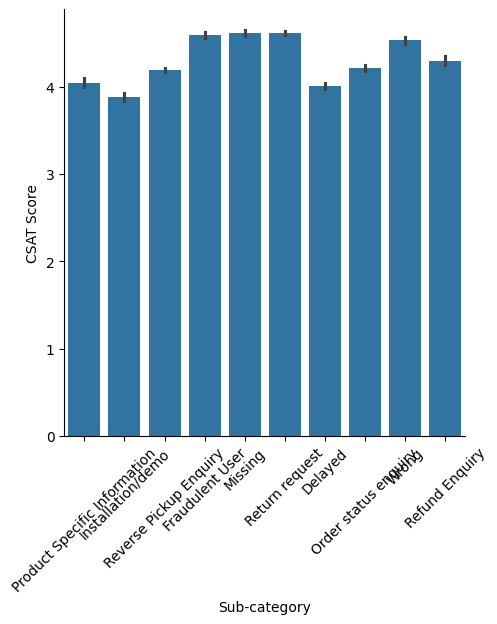

In [21]:
top_sub = CS_data["Sub-category"].value_counts().head(10).index
sub_data = CS_data[CS_data["Sub-category"].isin(top_sub)]
sns.catplot(data=sub_data, x="Sub-category", y="CSAT Score", kind="bar")
plt.xticks(rotation=45)
plt.show()

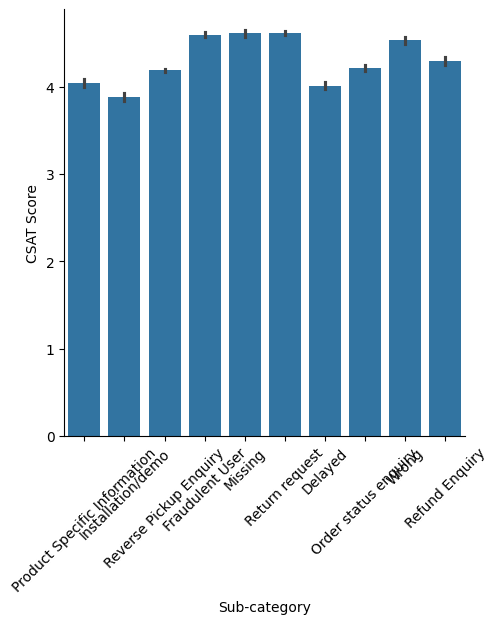

In [22]:
top_sub = CS_data["Sub-category"].value_counts().head(10).index
sub_data = CS_data[CS_data["Sub-category"].isin(top_sub)]
sns.catplot(data=sub_data, x="Sub-category", y="CSAT Score", kind="bar")
plt.xticks(rotation=45)
plt.show()

In [23]:
CS_data["Customer Remarks"].value_counts().head(20)

Customer Remarks
Good             1390
Good             1158
Very good         569
Nice              316
Thanks            276
Ok                259
No                258
Thank you         244
Nice              239
Very good         236
Excellent         171
Thanks            159
Good ??           148
Good service      133
Very nice         122
Thank you          97
??                 95
Nothing            88
5                  76
Good job           71
Name: count, dtype: int64

In [24]:
CS_data["Customer_City"].value_counts().head(20)

Customer_City
HYDERABAD      722
NEW DELHI      688
PUNE           435
MUMBAI         406
BANGALORE      352
CHENNAI        271
KOLKATA        270
LUCKNOW        254
AHMEDABAD      253
JAIPUR         243
GURGAON        215
PATNA          199
SURAT          175
ALLAHABAD      161
KANPUR         138
VARANASI       137
THANE          129
GHAZIABAD      120
BHUBANESWAR    117
VADODARA       105
Name: count, dtype: int64

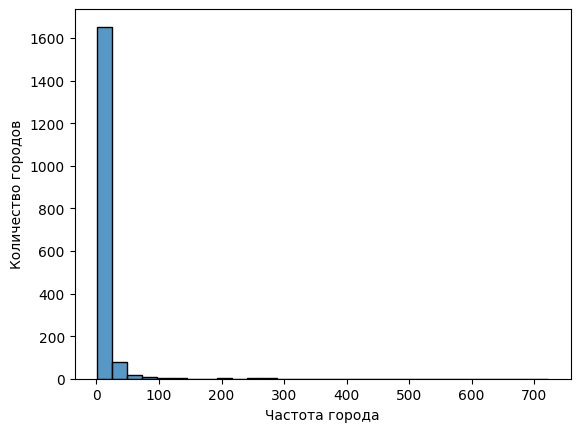

In [25]:
city_counts = CS_data["Customer_City"].value_counts()
sns.histplot(city_counts.values, bins=30)
plt.xlabel("Частота города")
plt.ylabel("Количество городов")
plt.show()

In [26]:
CS_data["Product_category"].value_counts()

Product_category
Electronics                    4706
LifeStyle                      4118
Books & General merchandise    3323
Mobile                         1758
Home                           1328
Home Appliences                1300
Furniture                       471
Affiliates                      166
GiftCard                         26
Name: count, dtype: int64

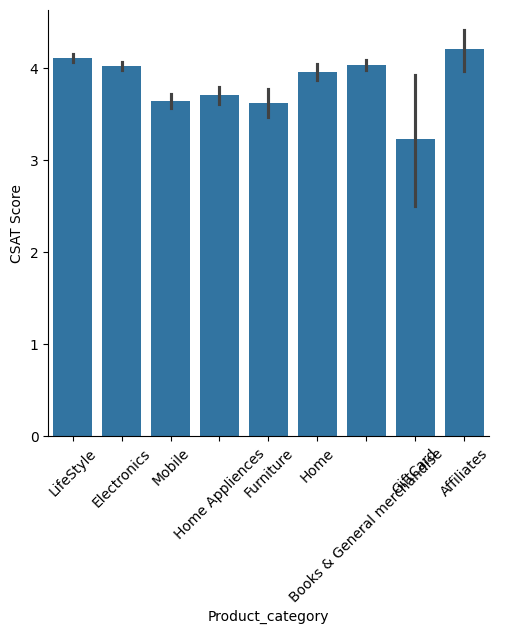

In [27]:
sns.catplot(data=CS_data, x="Product_category", y="CSAT Score", kind="bar")
plt.xticks(rotation=45)
plt.show()

In [28]:
CS_data["Agent_name"].value_counts().head(20)

Agent_name
Wendy Taylor           429
Timothy Huff           265
David Smith            264
Jamie Smith            253
Kayla Wilson           216
Mrs. Jennifer Stone    200
Julie Williams         200
Sharon Bullock         195
Matthew White PhD      192
Tina Harrington        177
Anthony Booth          177
Kristin Campbell       176
Rebecca Walker         176
Brianna Wolf           176
Jennifer Hernandez     174
Rebecca Graham         173
William Carey DVM      169
Ryan Thompson          167
Brandon Frost          161
Brian Young            160
Name: count, dtype: int64

In [29]:
CS_data["Supervisor"].value_counts().head(20)

Supervisor
Carter Park         4273
Elijah Yamaguchi    3855
Zoe Yamamoto        3551
Nathan Patel        3549
Noah Patel          3434
Ava Wong            3373
Emma Park           3290
Mia Patel           3279
Evelyn Kimura       2974
Aiden Patel         2892
Madison Kim         2772
William Park        2692
Scarlett Chen       2676
Emily Yamashita     2581
Jackson Park        2571
Brayden Wong        2540
Logan Lee           2466
Olivia Wang         2233
Abigail Suzuki      2222
Olivia Suzuki       2193
Name: count, dtype: int64

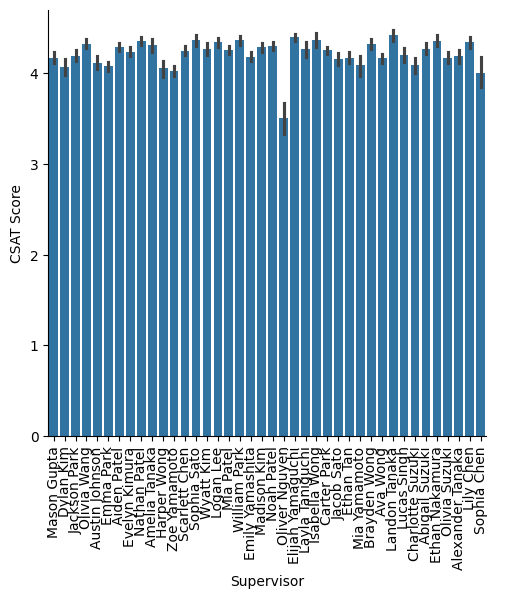

In [30]:
sns.catplot(data=CS_data, x="Supervisor", y="CSAT Score", kind="bar")
plt.xticks(rotation=90)
plt.show()

In [31]:
CS_data["Manager"].value_counts()

Manager
John Smith         25261
Michael Lee        17600
Jennifer Nguyen    15897
Emily Chen         14062
William Kim         8568
Olivia Tan          4519
Name: count, dtype: int64

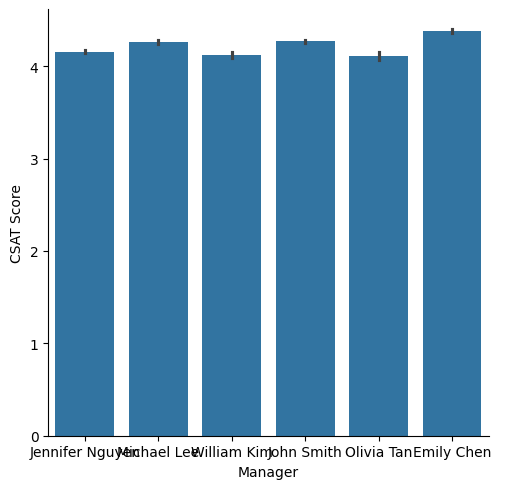

In [32]:
sns.catplot(data=CS_data, x="Manager", y="CSAT Score", kind="bar")
plt.show()

In [33]:
CS_data["Tenure Bucket"].value_counts()

Tenure Bucket
>90                30660
On Job Training    25523
31-60              11665
0-30               11318
61-90               6741
Name: count, dtype: int64

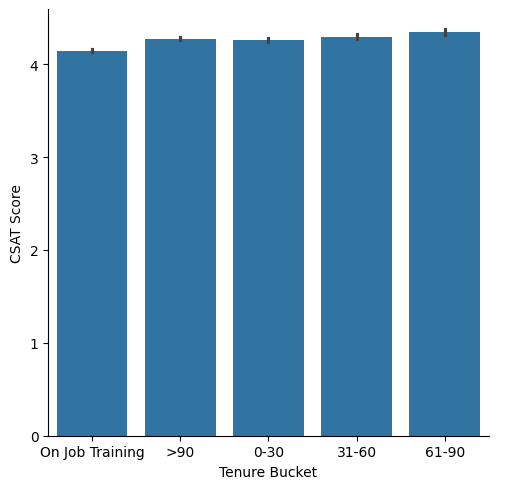

In [34]:
sns.catplot(data=CS_data, x="Tenure Bucket", y="CSAT Score", kind="bar")
plt.show()

In [35]:
CS_data["Agent Shift"].value_counts()

Agent Shift
Morning      41426
Evening      33677
Afternoon     5840
Split         3648
Night         1316
Name: count, dtype: int64

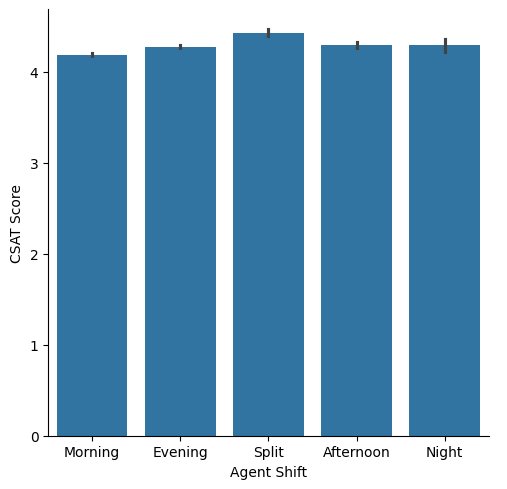

In [36]:
sns.catplot(data=CS_data, x="Agent Shift", y="CSAT Score", kind="bar")
plt.show()

In [37]:
CS_data["Customer Remarks New"] = (CS_data["Customer Remarks"].str.len() > 3).astype(int)
CS_data["Customer Remarks New"].value_counts()

Customer Remarks New
0    58502
1    27405
Name: count, dtype: int64

In [38]:
CS_data["Is_order"] = (CS_data["Order_id"].isna()).astype(int)
CS_data["Is_order"].value_counts()

Is_order
0    67675
1    18232
Name: count, dtype: int64

In [39]:
top_subcats = ["Reverse Pickup Enquiry", "Return request", "Delayed", 
               "Order status enquiry", "Installation/demo", "Fraudulent User", 
               "Product Specific Information"]
CS_data.loc[~CS_data["Sub-category"].isin(top_subcats), "Sub-category"] = "Other"
CS_data["Sub-category"].value_counts()

Sub-category
Other                           28872
Reverse Pickup Enquiry          22389
Return request                   8523
Delayed                          7388
Order status enquiry             6922
Installation/demo                4116
Fraudulent User                  4108
Product Specific Information     3589
Name: count, dtype: int64

In [40]:
CS_data['Agent_count'] = CS_data.groupby(["Agent_name"])["Agent_name"].transform('count')
CS_data['Agent_count'].describe()

count    85907.000000
mean        82.733433
std         47.494745
min         20.000000
25%         53.000000
50%         75.000000
75%        102.000000
max        429.000000
Name: Agent_count, dtype: float64

In [41]:
CS_data['Sups_no_agents'] = CS_data.groupby(["Supervisor"])["Agent_name"].transform('nunique')
CS_data['Sups_no_agents'].describe()

count    85907.000000
mean        41.358690
std         15.862947
min          5.000000
25%         29.000000
50%         41.000000
75%         55.000000
max         70.000000
Name: Sups_no_agents, dtype: float64

In [42]:
CS_data['Product_category'] = CS_data['Product_category'].fillna('unknown')

In [43]:
CS_data['connected_handling_time'] = CS_data['connected_handling_time'].fillna('0')

In [44]:
# Если Pclass уже числовой, пропустить. Иначе:
T_data['Pclass'].replace({'first':1, 'second':2, 'third':3}, inplace=True)

/var/folders/nx/cvp4nbcx5075w7wjhzyfgyd40000gn/T/ipykernel_39120/2380588237.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  T_data['Pclass'].replace({'first':1, 'second':2, 'third':3}, inplace=True)


0      3
1      1
2      3
3      1
4      3
      ..
886    2
887    1
888    3
889    1
890    3
Name: Pclass, Length: 891, dtype: object

In [45]:
OH_embarked = OneHotEncoder(sparse_output=False)
dummies = pd.DataFrame(OH_embarked.fit_transform(T_data[['Embarked']]),
                       columns=OH_embarked.get_feature_names_out(['Embarked']),
                       index=T_data.index)
T_dummies = pd.concat([T_data, dummies], axis=1).drop(['Embarked'], axis=1)
T_dummies.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S,Embarked_nan
0,0,1,0,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,0.0,0.0,1.0,0.0
1,1,2,1,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1.0,0.0,0.0,0.0
2,2,3,1,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0,0.0,1.0,0.0
3,3,4,1,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,0.0,0.0,1.0,0.0
4,4,5,0,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,0.0,0.0,1.0,0.0


In [46]:
CS_dropped = CS_data.drop([
    "Unique id", "Sub-category", "Customer Remarks", "Customer_City", 
    "Agent_name", "Supervisor", "Order_id", "order_date_time",
    "Issue_reported at", "issue_responded", "Survey_response_Date", "Item_price"
], axis=1)
CS_dropped.info()

<class 'pandas.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   channel_name             85907 non-null  str   
 1   category                 85907 non-null  str   
 2   Product_category         85907 non-null  str   
 3   connected_handling_time  85907 non-null  object
 4   Manager                  85907 non-null  str   
 5   Tenure Bucket            85907 non-null  str   
 6   Agent Shift              85907 non-null  str   
 7   CSAT Score               85907 non-null  int64 
 8   Customer Remarks New     85907 non-null  int64 
 9   Is_order                 85907 non-null  int64 
 10  Agent_count              85907 non-null  int64 
 11  Sups_no_agents           85907 non-null  int64 
dtypes: int64(5), object(1), str(6)
memory usage: 7.9+ MB


In [47]:
CS_dummies = pd.get_dummies(CS_dropped)
print(CS_dummies.shape)
CS_dummies.head()

(85907, 258)


,CSAT Score,Customer Remarks New,Is_order,Agent_count,Sups_no_agents,channel_name_Email,channel_name_Inbound,channel_name_Outcall,category_App/website,category_Cancellation,...,Tenure Bucket_0-30,Tenure Bucket_31-60,Tenure Bucket_61-90,Tenure Bucket_>90,Tenure Bucket_On Job Training,Agent Shift_Afternoon,Agent Shift_Evening,Agent Shift_Morning,Agent Shift_Night,Agent Shift_Split
0,5,0,0,42,41,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
1,5,0,0,32,17,False,False,True,False,False,...,False,False,False,True,False,False,False,True,False,False
2,5,0,0,35,46,False,True,False,False,False,...,False,False,False,False,True,False,True,False,False,False
3,5,0,0,48,28,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
4,5,0,0,124,29,False,True,False,False,True,...,True,False,False,False,False,False,False,True,False,False


# Задание для самостоятельного решения

## Задание 1. Визуализация распределения признаков

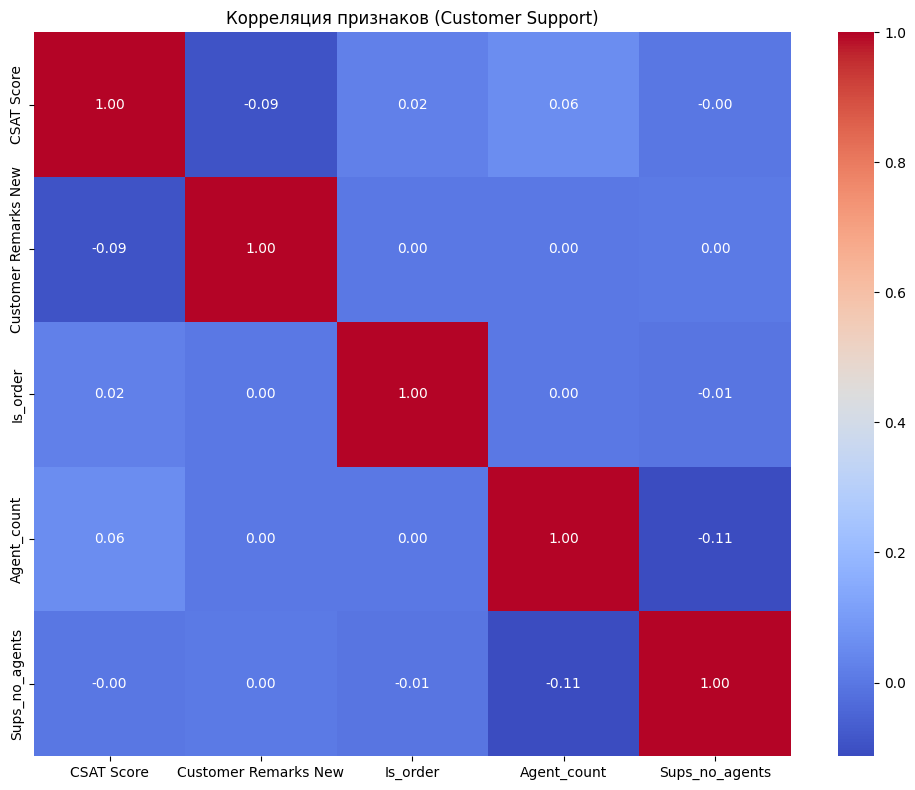

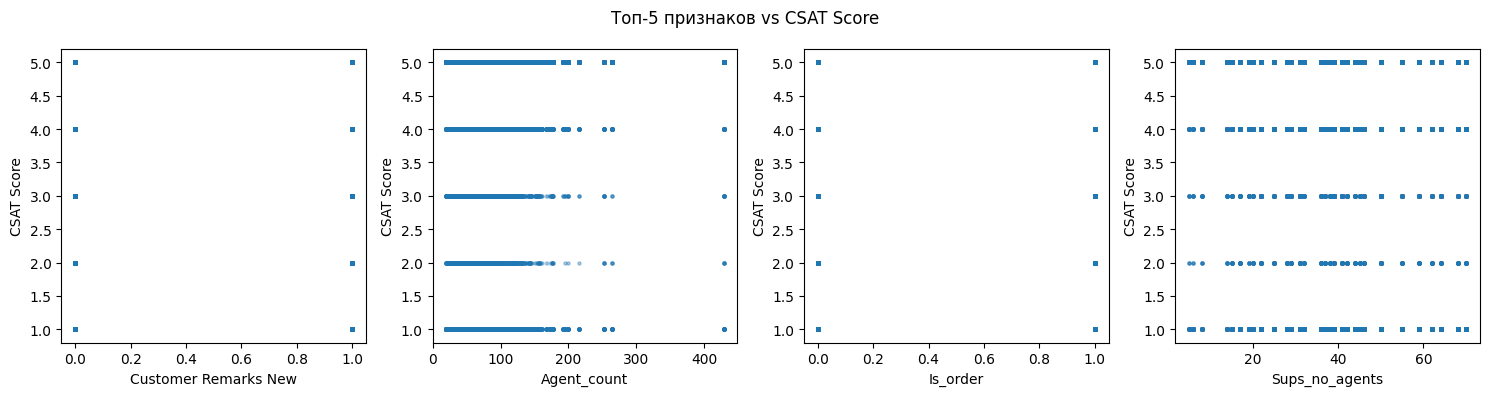

In [48]:
# Тепловая карта корреляций числовых признаков
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = CS_dropped.select_dtypes(include='number')
corr = num_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция признаков (Customer Support)')
plt.tight_layout()
plt.show()

# Совместное распределение с целевой переменной
if 'CSAT Score' in CS_dropped.columns:
    target = 'CSAT Score'
    top = corr[target].abs().sort_values(ascending=False).drop(target).head(5).index
    fig, axes = plt.subplots(1, len(top), figsize=(15, 4))
    for ax, col in zip(axes, top):
        ax.scatter(CS_dropped[col], CS_dropped[target], alpha=0.2, s=5)
        ax.set_xlabel(col); ax.set_ylabel(target)
    plt.suptitle('Топ-5 признаков vs CSAT Score')
    plt.tight_layout()
    plt.show()


## Задание 2. Дерево решений на Customer Support

Accuracy: 0.6950


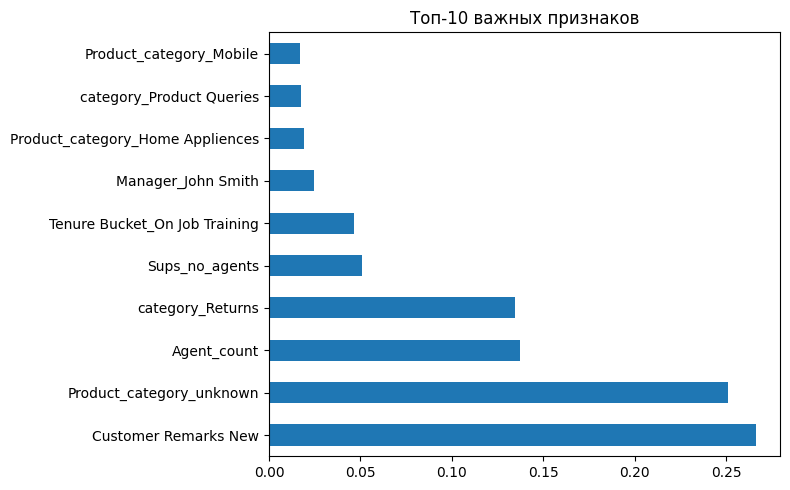

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd

# Используем CS_dummies (уже закодированный датасет)
target_col = 'CSAT Score'
X_cs = CS_dummies.drop(columns=[target_col], errors='ignore')
y_cs = CS_dropped[target_col]

X_tr, X_te, y_tr, y_te = train_test_split(X_cs, y_cs, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_tr, y_tr)
print(f'Accuracy: {accuracy_score(y_te, dt.predict(X_te)):.4f}')

# Важность признаков
imp = pd.Series(dt.feature_importances_, index=X_cs.columns)
top10 = imp.sort_values(ascending=False).head(10)
top10.plot(kind='barh', figsize=(8, 5), title='Топ-10 важных признаков')
plt.tight_layout()
plt.show()


## Задание 3. Разбиение на train/test с консистентным преобразованием

In [50]:
from sklearn.preprocessing import StandardScaler

# Разбиваем ДО преобразований
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_cs, y_cs, test_size=0.2, random_state=42)

# Обучаем scaler только на train, применяем к обоим
scaler = StandardScaler()
X_tr2_sc = scaler.fit_transform(X_tr2)
X_te2_sc = scaler.transform(X_te2)  # transform, не fit_transform!

dt2 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt2.fit(X_tr2_sc, y_tr2)
print(f'Accuracy (с масштабированием): {accuracy_score(y_te2, dt2.predict(X_te2_sc)):.4f}')
print('Scaler обучался только на train — нет утечки данных')


Accuracy (с масштабированием): 0.6950
Scaler обучался только на train — нет утечки данных


## Задание 4. Полный анализ Титаник

In [53]:
url_titanic = "https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML5.3%20categorical%20features/data/titanic.csv"
titanic = pd.read_csv(url_titanic)

print(titanic.shape)
print(titanic.dtypes)
print(titanic.isnull().sum()[titanic.isnull().sum() > 0])


(891, 13)
Unnamed: 0       int64
PassengerId      int64
Survived         int64
Pclass             str
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object
Age         177
Cabin       687
Embarked      2
dtype: int64


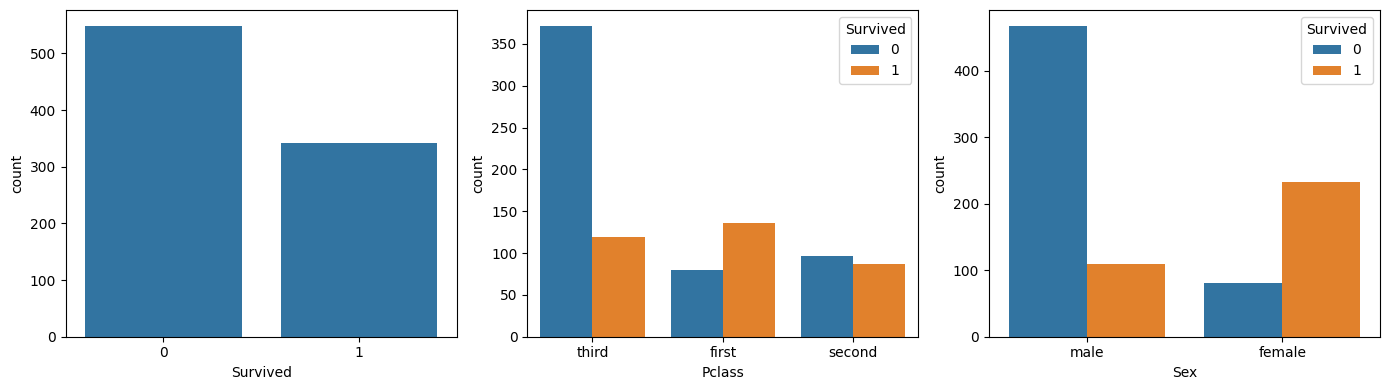

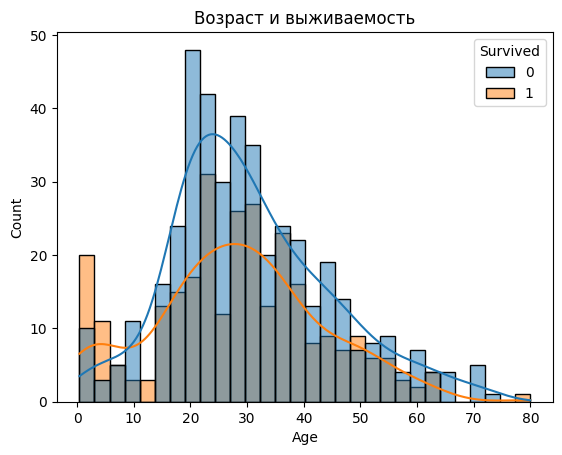

In [54]:
# Визуализации
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.countplot(x='Survived', data=titanic, ax=axes[0])
sns.countplot(x='Pclass', hue='Survived', data=titanic, ax=axes[1])
sns.countplot(x='Sex', hue='Survived', data=titanic, ax=axes[2])
plt.tight_layout(); plt.show()

# Возраст vs выживаемость
sns.histplot(data=titanic, x='Age', hue='Survived', bins=30, kde=True)
plt.title('Возраст и выживаемость'); plt.show()


In [55]:
from sklearn.linear_model import LogisticRegression

# Подготовка: заполнение пропусков, кодирование
t = titanic.copy()
t['Age'].fillna(t['Age'].median(), inplace=True)
t['Embarked'].fillna(t['Embarked'].mode()[0], inplace=True)
t['Sex'] = (t['Sex'] == 'male').astype(int)
t = pd.get_dummies(t, columns=['Embarked'], drop_first=True)
t.drop(columns=['Name','Ticket','Cabin'], inplace=True, errors='ignore')

X_t = t.drop('Survived', axis=1)
y_t = t['Survived']
X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42, stratify=y_t)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_tr_t, y_tr_t)
print(f'Titanic accuracy: {accuracy_score(y_te_t, lr.predict(X_te_t)):.4f}')

imp_t = pd.Series(abs(lr.coef_[0]), index=X_t.columns).sort_values(ascending=False)
imp_t.plot(kind='barh', figsize=(7,5), title='Важность признаков (Титаник)')
plt.tight_layout(); plt.show()


/var/folders/nx/cvp4nbcx5075w7wjhzyfgyd40000gn/T/ipykernel_39120/3188065479.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  t['Age'].fillna(t['Age'].median(), inplace=True)
/var/folders/nx/cvp4nbcx5075w7wjhzyfgyd40000gn/T/ipykernel_39120/3188065479.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Ser

ValueError: could not convert string to float: 'third'

## Задание 5. Проверка целесообразности преобразований

In [ ]:
from sklearn.tree import DecisionTreeClassifier

results = {}

# Базовый: только числовые признаки без дополнительных преобразований
t_base = titanic.copy()
t_base['Age'].fillna(t_base['Age'].median(), inplace=True)
t_base['Sex'] = (t_base['Sex'] == 'male').astype(int)
t_base = t_base[['Pclass','Sex','Age','SibSp','Parch','Fare','Survived']].dropna()
X_b, y_b = t_base.drop('Survived',axis=1), t_base['Survived']
Xtr,Xte,ytr,yte = train_test_split(X_b, y_b, test_size=0.2, random_state=42, stratify=y_b)
results['base'] = accuracy_score(yte, DecisionTreeClassifier(max_depth=5,random_state=42).fit(Xtr,ytr).predict(Xte))

# +OHE Embarked
t2 = titanic.copy()
t2['Age'].fillna(t2['Age'].median(), inplace=True)
t2['Embarked'].fillna(t2['Embarked'].mode()[0], inplace=True)
t2['Sex'] = (t2['Sex'] == 'male').astype(int)
t2 = pd.get_dummies(t2[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Survived']].dropna(), columns=['Embarked'])
X2, y2 = t2.drop('Survived',axis=1), t2['Survived']
Xtr2,Xte2,ytr2,yte2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)
results['+Embarked OHE'] = accuracy_score(yte2, DecisionTreeClassifier(max_depth=5,random_state=42).fit(Xtr2,ytr2).predict(Xte2))

for name, acc in results.items():
    print(f'{name}: {acc:.4f}')


## Задание 6. Воспроизводимый код обработки данных

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
TEST_SIZE = 0.2

def preprocess_titanic(df):
    """Воспроизводимая обработка Титаника"""
    df = df.copy()
    # Заполнение пропусков
    df['Age'].fillna(df['Age'].median(), inplace=True)
    df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
    df['Fare'].fillna(df['Fare'].median(), inplace=True)
    # Кодирование
    df['Sex'] = (df['Sex'] == 'male').astype(int)
    df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
    # Удаление ненужных
    df.drop(columns=['Name','Ticket','Cabin','PassengerId'], inplace=True, errors='ignore')
    return df

def split_data(df, target, test_size=TEST_SIZE, random_state=RANDOM_STATE):
    """Разбиение с фиксированным seed"""
    X = df.drop(target, axis=1)
    y = df[target]
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

# Демонстрация
t_clean = preprocess_titanic(titanic)
X_tr_f, X_te_f, y_tr_f, y_te_f = split_data(t_clean, 'Survived')
print(f'Train: {X_tr_f.shape}, Test: {X_te_f.shape}')
print('Признаки:', list(X_tr_f.columns))
